In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle 
from os import path
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [77]:
BASE_DIR = Path.cwd()  
BASE_DIR=BASE_DIR.parent
print("BASE_DIR:", BASE_DIR)


df_train = pd.read_csv(BASE_DIR /"Dataset\\UNSW_NB15_testing-set.csv")
df_test = pd.read_csv(BASE_DIR/"Dataset\\UNSW_NB15_training-set.csv")
data=pd.concat([df_train, df_test], ignore_index=True)
data.head()

BASE_DIR: c:\Users\Asus\OneDrive\Desktop\github projects\Navy_waf_ml


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  si

In [79]:


data[data['service']=='-']

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,...,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257457,175126,0.653375,tcp,-,FIN,10,8,564,354,26.018748,...,1,1,0,0,0,18,1,0,Reconnaissance,1
257511,175180,0.695566,tcp,-,FIN,10,8,564,354,24.440528,...,1,1,0,0,0,3,1,0,Reconnaissance,1
257523,175192,0.962856,tcp,-,FIN,24,60,1256,59374,86.201883,...,1,1,0,0,0,1,1,0,Exploits,1
257609,175278,3.719110,tcp,-,FIN,66,340,3086,426483,108.897021,...,1,1,0,0,0,2,1,0,Exploits,1


In [80]:
data['service'].replace('-',np.nan,inplace=True)

In [81]:
data.isnull().sum()

id                        0
dur                       0
proto                     0
service              141321
state                     0
spkts                     0
dpkts                     0
sbytes                    0
dbytes                    0
rate                      0
sttl                      0
dttl                      0
sload                     0
dload                     0
sloss                     0
dloss                     0
sinpkt                    0
dinpkt                    0
sjit                      0
djit                      0
swin                      0
stcpb                     0
dtcpb                     0
dwin                      0
tcprtt                    0
synack                    0
ackdat                    0
smean                     0
dmean                     0
trans_depth               0
response_body_len         0
ct_srv_src                0
ct_state_ttl              0
ct_dst_ltm                0
ct_src_dport_ltm          0
ct_dst_sport_ltm    

In [82]:
data.shape
     

(257673, 45)

In [83]:

data.dropna(inplace=True)

In [84]:


data.shape

(116352, 45)

In [85]:


data['attack_cat'].value_counts()


Generic           57956
Normal            29113
Exploits          21480
DoS                2508
Fuzzers            2266
Reconnaissance     2207
Analysis            564
Worms               148
Backdoor            110
Name: attack_cat, dtype: int64

In [86]:

data['state'].value_counts()

INT    57894
FIN    47350
CON    10859
REQ      234
RST       14
ACC        1
Name: state, dtype: int64

In [87]:
data

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
35,36,0.983874,tcp,http,FIN,10,8,816,1172,17.278635,...,1,2,0,0,1,1,3,0,Normal,0
40,41,1.535254,tcp,http,FIN,10,10,826,1266,12.375802,...,1,2,0,0,1,1,3,0,Normal,0
45,46,1.059359,tcp,http,FIN,10,8,830,1134,16.047441,...,1,1,0,0,1,3,1,0,Normal,0
49,50,0.990548,tcp,http,FIN,10,10,804,1414,19.181301,...,1,2,0,0,1,1,2,0,Normal,0
72,73,1.303518,tcp,http,FIN,12,8,898,1120,14.575939,...,1,1,0,0,1,2,1,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257667,175336,0.000006,udp,dns,INT,2,0,114,0,166666.660800,...,17,45,0,0,0,33,45,0,Generic,1
257668,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
257670,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
257671,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1


In [88]:
features=pd.read_csv(BASE_DIR/"Dataset//NUSW_NB15_features.csv", encoding="latin1")

In [89]:
features.head()
     


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol


In [90]:
features['Type '] = features['Type '].str.lower()

In [91]:
# selecting column names of all data types
nominal_names = features['Name'][features['Type ']=='nominal']
integer_names = features['Name'][features['Type ']=='integer']
binary_names = features['Name'][features['Type ']=='binary']
float_names = features['Name'][features['Type ']=='float']

In [92]:
# selecting common column names from dataset and feature dataset
cols = data.columns
nominal_names = cols.intersection(nominal_names)
integer_names = cols.intersection(integer_names)
binary_names = cols.intersection(binary_names)
float_names = cols.intersection(float_names)

In [93]:
# Converting integer columns to numeric
for c in integer_names:
  pd.to_numeric(data[c])
# Converting binary columns to numeric
for c in binary_names:
  pd.to_numeric(data[c])
# Converting float columns to numeric
for c in float_names:
  pd.to_numeric(data[c])    

In [94]:

data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 116352 entries, 35 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 116352 non-null  int64  
 1   dur                116352 non-null  float64
 2   proto              116352 non-null  object 
 3   service            116352 non-null  object 
 4   state              116352 non-null  object 
 5   spkts              116352 non-null  int64  
 6   dpkts              116352 non-null  int64  
 7   sbytes             116352 non-null  int64  
 8   dbytes             116352 non-null  int64  
 9   rate               116352 non-null  float64
 10  sttl               116352 non-null  int64  
 11  dttl               116352 non-null  int64  
 12  sload              116352 non-null  float64
 13  dload              116352 non-null  float64
 14  sloss              116352 non-null  int64  
 15  dloss              116352 non-null  int64  
 16  s

In [95]:
data

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
35,36,0.983874,tcp,http,FIN,10,8,816,1172,17.278635,...,1,2,0,0,1,1,3,0,Normal,0
40,41,1.535254,tcp,http,FIN,10,10,826,1266,12.375802,...,1,2,0,0,1,1,3,0,Normal,0
45,46,1.059359,tcp,http,FIN,10,8,830,1134,16.047441,...,1,1,0,0,1,3,1,0,Normal,0
49,50,0.990548,tcp,http,FIN,10,10,804,1414,19.181301,...,1,2,0,0,1,1,2,0,Normal,0
72,73,1.303518,tcp,http,FIN,12,8,898,1120,14.575939,...,1,1,0,0,1,2,1,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257667,175336,0.000006,udp,dns,INT,2,0,114,0,166666.660800,...,17,45,0,0,0,33,45,0,Generic,1
257668,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
257670,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
257671,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1


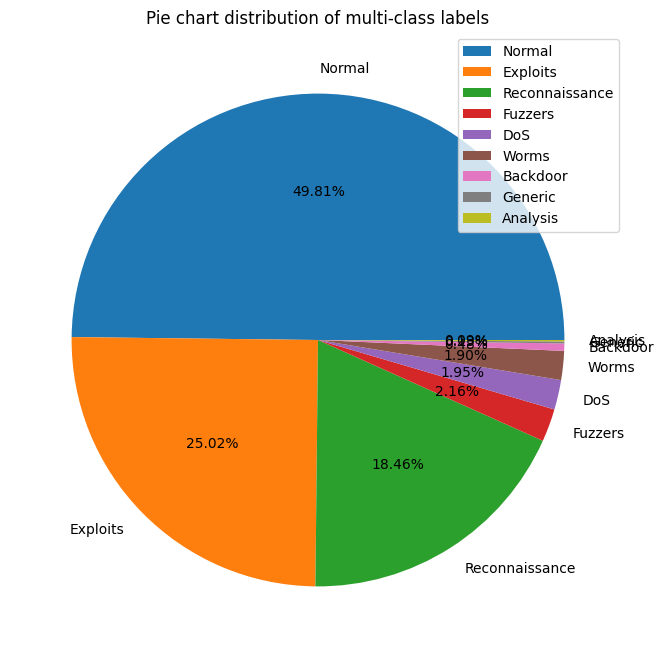

In [96]:
plt.figure(figsize=(8,8))
plt.pie(data.attack_cat.value_counts(),labels=data.attack_cat.unique(),autopct='%0.2f%%')
plt.title('Pie chart distribution of multi-class labels')
plt.legend(loc='best')
plt.savefig('Pie_chart_multi3.png')
plt.show()

In [97]:
num_col = data.select_dtypes(include='number').columns
# selecting categorical data attributes
cat_col = data.columns.difference(num_col)
cat_col = cat_col[1:]
cat_col

Index(['proto', 'service', 'state'], dtype='object')

In [98]:
# creating a dataframe with only categorical attributes
data_cat = data[cat_col].copy()
data_cat.head()

,proto,service,state
35,tcp,http,FIN
40,tcp,http,FIN
45,tcp,http,FIN
49,tcp,http,FIN
72,tcp,http,FIN


In [99]:
# one-hot-encoding categorical attributes using pandas.get_dummies() function
data_cat = pd.get_dummies(data_cat,columns=cat_col)

In [100]:
data_cat.head()


,proto_tcp,proto_udp,service_dhcp,service_dns,service_ftp,service_ftp-data,service_http,service_irc,service_pop3,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_ACC,state_CON,state_FIN,state_INT,state_REQ,state_RST
35,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
40,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
45,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
49,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
72,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [101]:
data.shape

(116352, 45)

In [102]:
data = pd.concat([data, data_cat],axis=1)

In [103]:
data.shape

(116352, 65)

In [104]:
data.drop(columns=cat_col,inplace=True)

In [105]:
data.shape

(116352, 62)

In [106]:
# selecting numeric attributes columns from data
num_col = list(data.select_dtypes(include='number').columns)
num_col.remove('id')
num_col.remove('label')
print(num_col)

['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'proto_tcp', 'proto_udp', 'service_dhcp', 'service_dns', 'service_ftp', 'service_ftp-data', 'service_http', 'service_irc', 'service_pop3', 'service_radius', 'service_smtp', 'service_snmp', 'service_ssh', 'service_ssl', 'state_ACC', 'state_CON', 'state_FIN', 'state_INT', 'state_REQ', 'state_RST']


In [107]:
# using minmax scaler for normalizing data
minmax_scale = MinMaxScaler(feature_range=(0, 1))
def normalization(df,col):
  for i in col:
    arr = df[i]
    arr = np.array(arr)
    df[i] = minmax_scale.fit_transform(arr.reshape(len(arr),1))
  return df

In [108]:
data.head()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,service_smtp,service_snmp,service_ssh,service_ssl,state_ACC,state_CON,state_FIN,state_INT,state_REQ,state_RST
35,36,0.983874,10,8,816,1172,17.278635,62,252,5976.375000,...,0,0,0,0,0,0,1,0,0,0
40,41,1.535254,10,10,826,1266,12.375802,62,252,3876.882812,...,0,0,0,0,0,0,1,0,0,0
45,46,1.059359,10,8,830,1134,16.047441,62,252,5641.147461,...,0,0,0,0,0,0,1,0,0,0
49,50,0.990548,10,10,804,1414,19.181301,62,252,5847.268066,...,0,0,0,0,0,0,1,0,0,0
72,73,1.303518,12,8,898,1120,14.575939,62,252,5057.083984,...,0,0,0,0,0,0,1,0,0,0


In [109]:
# calling normalization() function
data = normalization(data.copy(),num_col)

In [110]:
data.head()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,service_smtp,service_snmp,service_ssh,service_ssl,state_ACC,state_CON,state_FIN,state_INT,state_REQ,state_RST
35,36,0.016398,0.000845,0.000726,0.000052,0.000080,0.000017,0.138393,0.992126,0.000003,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
40,41,0.025588,0.000845,0.000908,0.000053,0.000086,0.000012,0.138393,0.992126,0.000002,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
45,46,0.017656,0.000845,0.000726,0.000053,0.000077,0.000016,0.138393,0.992126,0.000002,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
49,50,0.016509,0.000845,0.000908,0.000051,0.000096,0.000019,0.138393,0.992126,0.000003,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
72,73,0.021725,0.001033,0.000726,0.000058,0.000076,0.000015,0.138393,0.992126,0.000002,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [111]:


# one-hot-encoding attack label
multi_data = data.copy()
multi_label = pd.DataFrame(multi_data.attack_cat)

In [112]:
multi_data = pd.get_dummies(multi_data,columns=['attack_cat'])

In [113]:
# label encoding (0,1,2,3,4,5,6,7,8) multi-class labels
le2 = preprocessing.LabelEncoder()
enc_label = multi_label.apply(le2.fit_transform)
multi_data['label'] = enc_label

In [114]:
le2.classes_

array(['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic',
       'Normal', 'Reconnaissance', 'Worms'], dtype=object)

In [115]:
np.save(BASE_DIR/"Model/le2_classes.npy",le2.classes_,allow_pickle=True)

In [116]:
num_col.append('label')

In [117]:
num_col = list(multi_data.select_dtypes(include='number').columns)

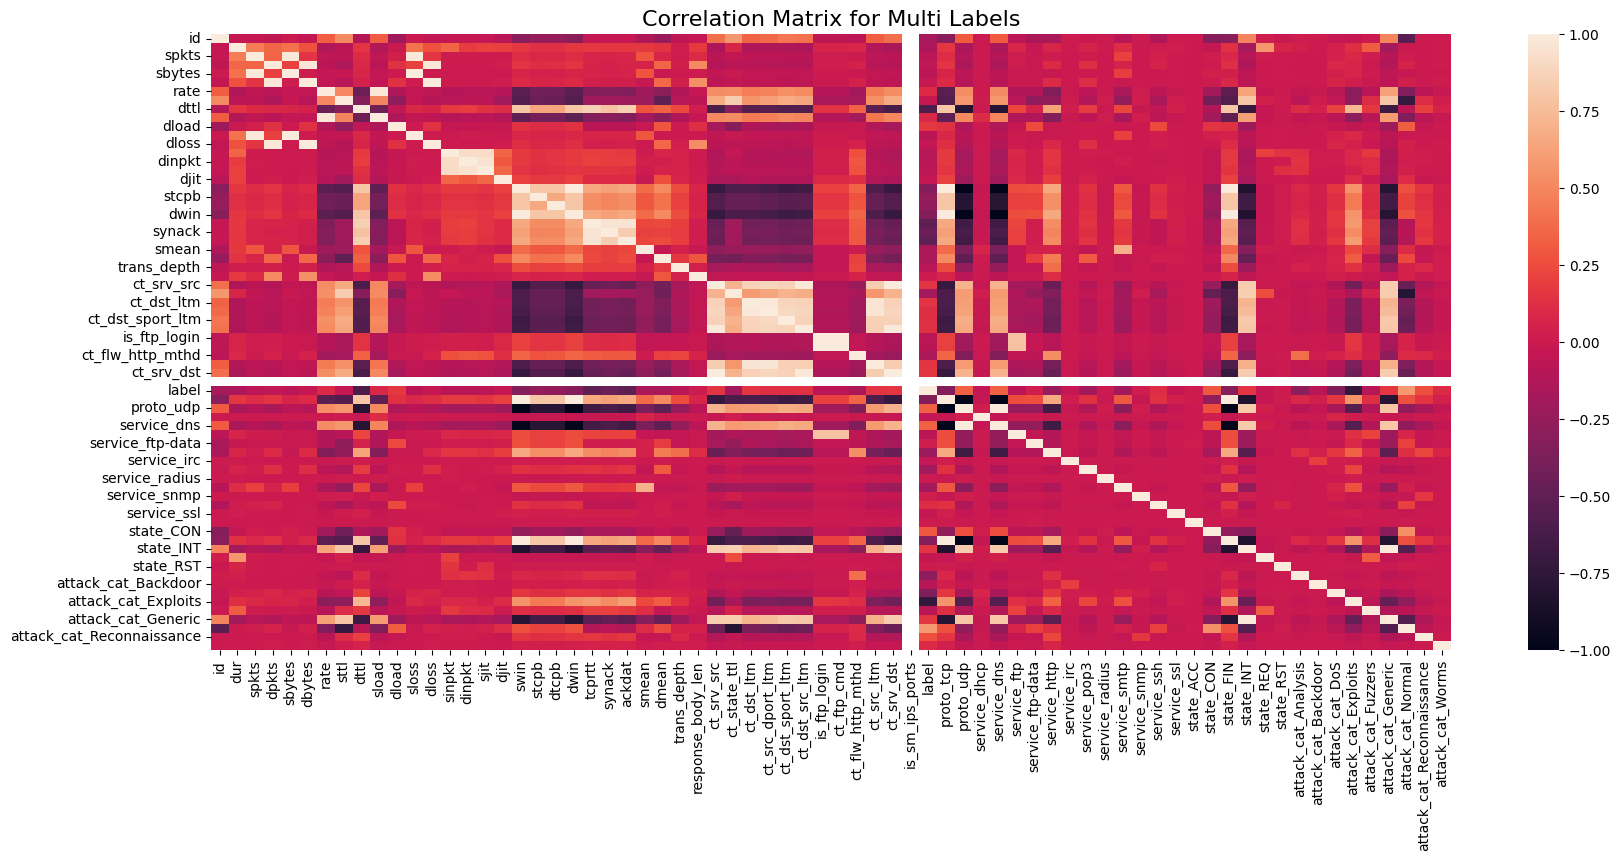

In [118]:
# Correlation Matrix for Multi-class Labels
plt.figure(figsize=(20,8))
corr_multi = multi_data[num_col].corr()
sns.heatmap(corr_multi,vmax=1.0,annot=False)
plt.title('Correlation Matrix for Multi Labels',fontsize=16)
plt.savefig('correlation_matrix_multi3.png')
plt.show()

In [119]:
# finding the attributes which have more than 0.3 correlation with encoded attack label attribute 
corr_ymulti = abs(corr_multi['label'])
highest_corr_multi = corr_ymulti[corr_ymulti >0.3]
highest_corr_multi.sort_values(ascending=True)

state_FIN              0.328058
proto_tcp              0.330215
swin                   0.330215
proto_udp              0.330215
dwin                   0.330234
service_dns            0.331124
attack_cat_DoS         0.353847
synack                 0.448737
tcprtt                 0.500531
ackdat                 0.512859
attack_cat_Normal      0.582817
dttl                   0.594611
attack_cat_Exploits    0.730763
label                  1.000000
Name: label, dtype: float64

In [120]:
# selecting attributes found by using pearson correlation coefficient
multi_cols = highest_corr_multi.index
multi_cols

Index(['dttl', 'swin', 'dwin', 'tcprtt', 'synack', 'ackdat', 'label',
       'proto_tcp', 'proto_udp', 'service_dns', 'state_FIN', 'attack_cat_DoS',
       'attack_cat_Exploits', 'attack_cat_Normal'],
      dtype='object')

In [121]:
# Multi-class labelled Dataset
multi_data = multi_data[multi_cols].copy()

In [122]:
multi_data.to_csv(BASE_DIR/"Dataset/multi_data.csv")
     

In [123]:
X = multi_data.drop(columns=['label'],axis=1)
Y = multi_data['label'] 

In [124]:
#dropping because those are labels
label_leak_cols = [
    "attack_cat_DoS",
    "attack_cat_Exploits",
    "attack_cat_Normal"
]
X_clean = X.drop(columns=label_leak_cols, errors="ignore")
print("Original feature count:", X.shape[1])
print("Clean feature count:", X_clean.shape[1])
print("Remaining columns:")
print(X_clean.columns.tolist())

Original feature count: 13
Clean feature count: 10
Remaining columns:
['dttl', 'swin', 'dwin', 'tcprtt', 'synack', 'ackdat', 'proto_tcp', 'proto_udp', 'service_dns', 'state_FIN']


In [125]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_clean)

joblib.dump(scaler, BASE_DIR /"Model/minmaxscaler.pkl")
print(scaler.n_features_in_)

10


In [126]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,Y,test_size=0.30, random_state=100)

In [138]:
rf_multi = RandomForestClassifier(
    # n_estimators=300,
    # max_depth=20,
    # min_samples_split=10,
    # min_samples_leaf=5,
    # max_features="sqrt",
    class_weight="balanced",
    random_state=50
    # n_jobs=-1
)

rf_multi.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=50)

In [139]:
y_pred = rf_multi.predict(X_test)

In [140]:
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred)*100)

R2 Score -  34.32160296416191
Accuracy -  87.71557898355583


In [141]:
print(classification_report(y_test, y_pred,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.65      0.47      0.55       145
      Backdoor       0.50      0.03      0.06        33
           DoS       0.17      0.05      0.08       770
      Exploits       0.66      0.87      0.75      6434
       Fuzzers       0.24      0.08      0.12       694
       Generic       0.99      0.99      0.99     17402
        Normal       0.93      0.87      0.90      8724
Reconnaissance       0.16      0.07      0.10       655
         Worms       0.27      0.06      0.10        49

      accuracy                           0.88     34906
     macro avg       0.51      0.39      0.40     34906
  weighted avg       0.86      0.88      0.86     34906



In [142]:
rf_multi_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
rf_multi_df.to_csv(BASE_DIR /"Dataset/rf_real_pred_multi3.csv")
rf_multi_df

,Actual,Predicted
211658,5,5
26791,6,6
226420,5,5
94256,6,6
129310,6,3
...,...,...
249919,5,5
112418,6,6
143461,3,7
65416,5,5


C:\Users\Asus\AppData\Local\Temp\ipykernel_2944\341947185.py:3: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  plt.plot(y_test[500:600].values, label="real_values", linewidth=2.0,color='lightcoral')


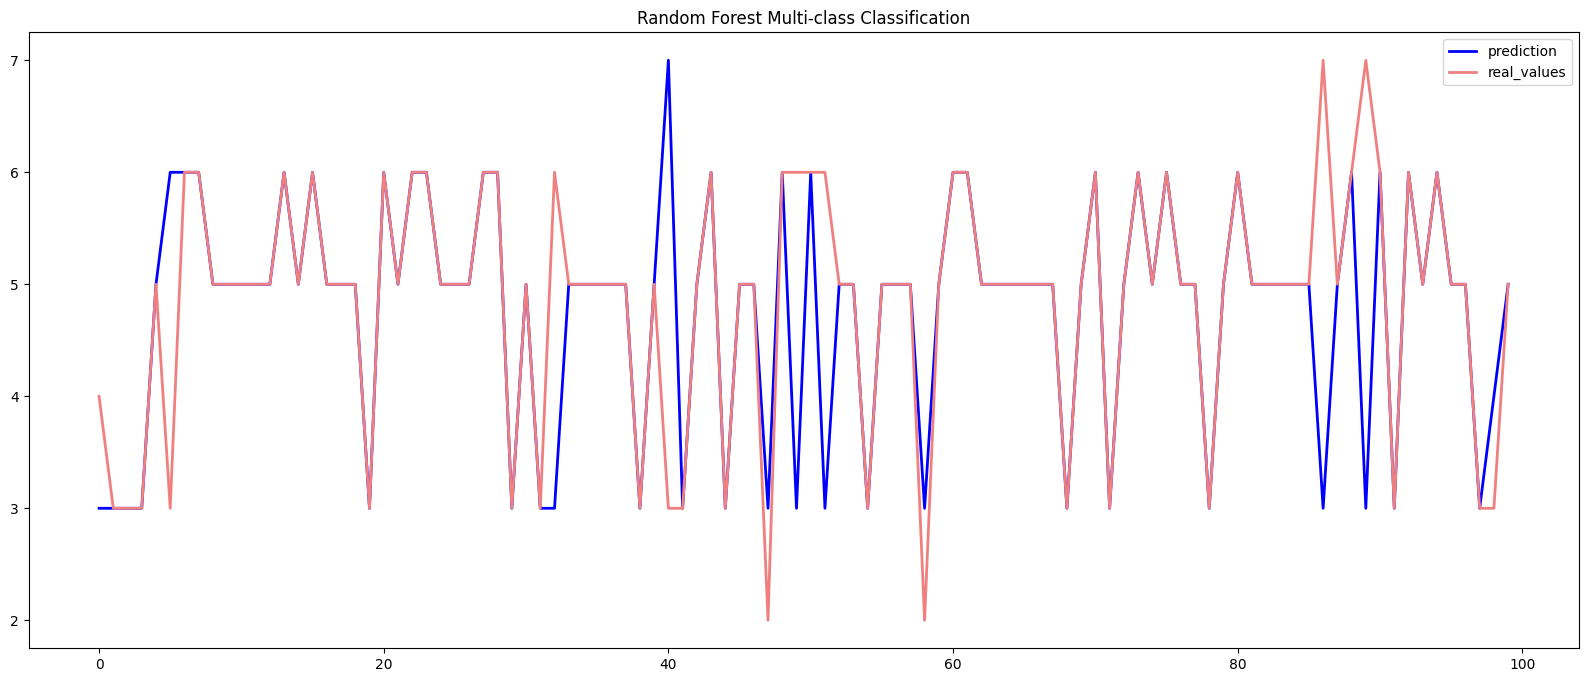

In [143]:
plt.figure(figsize=(20,8))
plt.plot(y_pred[500:600], label="prediction", linewidth=2.0,color='blue')
plt.plot(y_test[500:600].values, label="real_values", linewidth=2.0,color='lightcoral')
plt.legend(loc="best")
plt.title("Random Forest Multi-class Classification")
plt.savefig('rf_real_pred_multi.png')
plt.show()

In [144]:
import pickle

with open(BASE_DIR /"Model/rf_multiclass_unsw.pkl", "wb") as f:
    pickle.dump(rf_multi, f)

print("Saved rf_multiclass_unsw.pkl")


Saved rf_multiclass_unsw.pkl


In [ ]:
import json

feature_columns = X_clean.columns.tolist()

with open(BASE_DIR /"Model"/"feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print("Saved feature_columns.json")
print("Number of features:", len(feature_columns))


Saved feature_columns.json
Number of features: 10
